# Question 8: Grid World Reinforcement Learning

In this problem, we implement Monte Carlo, TD(0), SARSA, and Q-Learning on a $4 \times 4$ Grid World.


## Environment

**Environment Setup:**
* **Grid:** $4 \times 4$
* **Start State:** Top-left $(0,0)$
* **Terminal State:** Bottom-right $(3,3)$
* **Actions:** Up, Down, Left, Right
* **Rewards:** $-1$ for all transitions, except $0$ when reaching the terminal state $(3,3)$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Environment Constants
GRID_SIZE = 4
START_STATE = (0, 0)
TERMINAL_STATE = (3, 3)
ACTIONS = ['UP', 'DOWN', 'LEFT', 'RIGHT']
ACTION_MAP = {
    'UP': (-1, 0),
    'DOWN': (1, 0),
    'LEFT': (0, -1),
    'RIGHT': (0, 1)
}

def step(state, action):
    """
    Simulates one step in the environment.
    Returns: next_state, reward, done
    """
    if state == TERMINAL_STATE:
        return state, 0, True

    row, col = state
    dr, dc = ACTION_MAP[action]
    
    # Calculate next position
    next_row, next_col = row + dr, col + dc
    
    # Boundary checks (stay in place if out of bounds)
    if next_row < 0 or next_row >= GRID_SIZE or next_col < 0 or next_col >= GRID_SIZE:
        next_state = state
    else:
        next_state = (next_row, next_col)
    
    # Determine reward and done flag
    if next_state == TERMINAL_STATE:
        reward = 0
        done = True
    else:
        reward = -1
        done = False
        
    return next_state, reward, done

def plot_value_function(V, title="State-Value Function"):
    """
    Heatmap visualization of the value function.
    """
    grid = np.zeros((GRID_SIZE, GRID_SIZE))
    for i in range(GRID_SIZE):
        for j in range(GRID_SIZE):
            grid[i, j] = V.get((i, j), 0)
            
    plt.figure(figsize=(6, 5))
    sns.heatmap(grid, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
    plt.title(title)
    plt.gca().invert_yaxis() # Match matrix coordinates with plot (0,0 at top-left visually if needed, but heatmap is usually standard)
    # Actually seaborn puts (0,0) at top-left by default, which matches matrix indexing.
    plt.show()

def plot_policy_from_q(Q, title="Learned Policy"):
    """
    Visualizes the greedy policy derived from Q-values.
    """
    grid = np.zeros((GRID_SIZE, GRID_SIZE), dtype=object)
    
    for i in range(GRID_SIZE):
        for j in range(GRID_SIZE):
            state = (i, j)
            if state == TERMINAL_STATE:
                grid[i, j] = 'T'
                continue
            
            # Find best action
            best_action = None
            best_val = -float('inf')
            for a in ACTIONS:
                if Q[(state, a)] > best_val:
                    best_val = Q[(state, a)]
                    best_action = a
            
            # Arrows for visualization
            arrows = {'UP': '↑', 'DOWN': '↓', 'LEFT': '←', 'RIGHT': '→'}
            grid[i, j] = arrows[best_action]

    # Create a simple plot of text
    fig, ax = plt.subplots()
    ax.set_axis_off()
    table = plt.table(cellText=grid, loc='center', cellLoc='center', bbox=[0,0,1,1])
    table.auto_set_font_size(False)
    table.set_fontsize(20)
    plt.title(title)
    plt.show()

## Part (a): Monte Carlo Prediction

* **Goal:** Estimate $V(s)$.
* **Policy:** Random (Equiprobable, $25\%$ for each action).

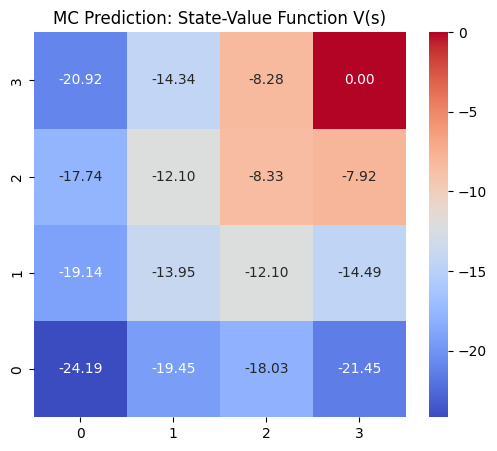

In [2]:
def monte_carlo_prediction(episodes=5000, gamma=1.0):
    # Initialize V(s) arbitrarily (0) and Returns(s)
    V = {}
    returns = {}
    states = [(i, j) for i in range(GRID_SIZE) for j in range(GRID_SIZE)]
    for s in states:
        V[s] = 0
        returns[s] = []
        
    for _ in range(episodes):
        # Generate an episode
        episode = []
        state = START_STATE
        while True:
            action = np.random.choice(ACTIONS)
            next_state, reward, done = step(state, action)
            episode.append((state, action, reward))
            if done:
                break
            state = next_state
            
        # Update V(s)
        G = 0
        visited_states = set()
        for i in range(len(episode) - 1, -1, -1):
            state, action, reward = episode[i]
            G = gamma * G + reward
            
            # First-visit check
            if state not in visited_states:
                visited_states.add(state)
                returns[state].append(G)
                V[state] = np.mean(returns[state])
                
    return V

# Run and Plot
V_mc = monte_carlo_prediction()
plot_value_function(V_mc, title="MC Prediction: State-Value Function V(s)")

## Part (b): TD(0) Prediction

* **Goal:** Estimate $V(s)$ using Temporal Difference.
* **Policy:** Random (Equiprobable).
* **Parameters:** $\alpha=0.1, \gamma=1.0$.

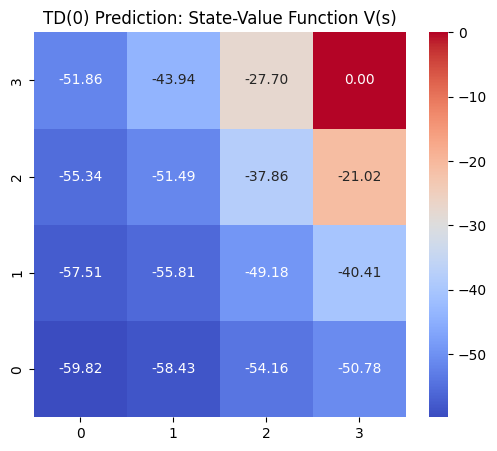

In [3]:
def td_0_prediction(episodes=5000, alpha=0.1, gamma=1.0):
    # Initialize V(s)
    V = {}
    states = [(i, j) for i in range(GRID_SIZE) for j in range(GRID_SIZE)]
    for s in states:
        V[s] = 0
        
    for _ in range(episodes):
        state = START_STATE
        while True:
            action = np.random.choice(ACTIONS)
            next_state, reward, done = step(state, action)
            
            # TD Update
            # V(s) <- V(s) + alpha * [R + gamma * V(s') - V(s)]
            target = reward + gamma * V[next_state]
            V[state] += alpha * (target - V[state])
            
            if done:
                break
            state = next_state
            
    return V

# Run and Plot
V_td = td_0_prediction()
plot_value_function(V_td, title="TD(0) Prediction: State-Value Function V(s)")

## Part (c): SARSA

* **Goal:** Estimate $Q(s,a)$ and find optimal policy.
* **Policy:** $\epsilon$-greedy ($\epsilon=0.1$).
* **Update:** On-policy $Q(S, A) \leftarrow Q(S, A) + \alpha [R + \gamma Q(S', A') - Q(S, A)]$.

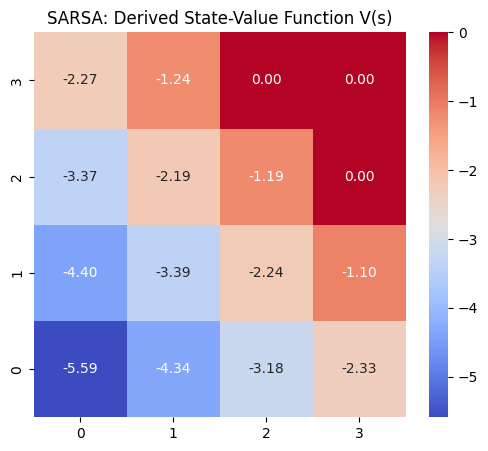

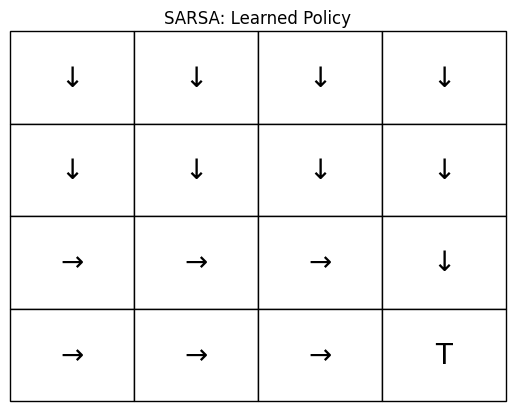

In [4]:
def get_epsilon_greedy_action(Q, state, epsilon=0.1):
    if np.random.rand() < epsilon:
        return np.random.choice(ACTIONS)
    else:
        # Greedy action (random tie-breaking)
        values = [Q[(state, a)] for a in ACTIONS]
        max_val = max(values)
        best_actions = [a for a, v in zip(ACTIONS, values) if v == max_val]
        return np.random.choice(best_actions)

def sarsa(episodes=10000, alpha=0.1, gamma=1.0, epsilon=0.1):
    # Initialize Q(s,a)
    Q = {}
    states = [(i, j) for i in range(GRID_SIZE) for j in range(GRID_SIZE)]
    for s in states:
        for a in ACTIONS:
            Q[(s, a)] = 0
            
    for _ in range(episodes):
        state = START_STATE
        action = get_epsilon_greedy_action(Q, state, epsilon)
        
        while True:
            next_state, reward, done = step(state, action)
            
            if done:
                target = reward # Q(terminal, .) = 0
                Q[(state, action)] += alpha * (target - Q[(state, action)])
                break
                
            next_action = get_epsilon_greedy_action(Q, next_state, epsilon)
            
            # SARSA Update
            target = reward + gamma * Q[(next_state, next_action)]
            Q[(state, action)] += alpha * (target - Q[(state, action)])
            
            state = next_state
            action = next_action
            
    return Q

# Run SARSA
Q_sarsa = sarsa()

# Extract V(s) from Q(s,a) for plotting: V(s) = max_a Q(s,a)
V_sarsa = {}
for i in range(GRID_SIZE):
    for j in range(GRID_SIZE):
        s = (i, j)
        V_sarsa[s] = max([Q_sarsa[(s, a)] for a in ACTIONS])

plot_value_function(V_sarsa, title="SARSA: Derived State-Value Function V(s)")
plot_policy_from_q(Q_sarsa, title="SARSA: Learned Policy")

## Part (d): Q-Learning

* **Goal:** Estimate $Q(s,a)$ (Off-policy).
* **Policy:** $\epsilon$-greedy ($\epsilon=0.1$).
* **Update:** $Q(S, A) \leftarrow Q(S, A) + \alpha [R + \gamma \max_{a} Q(S', a) - Q(S, A)]$.

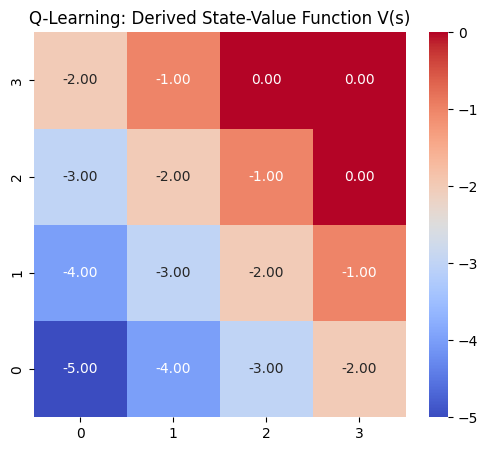

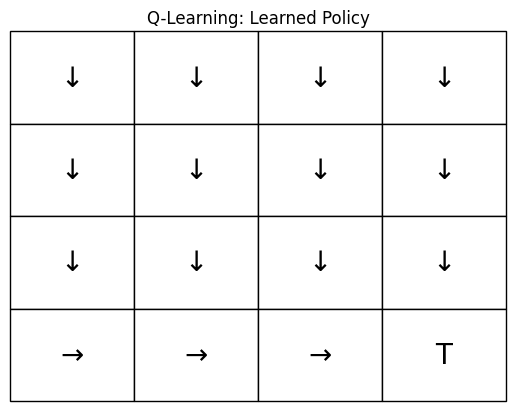

In [5]:
def q_learning(episodes=10000, alpha=0.1, gamma=1.0, epsilon=0.1):
    # Initialize Q(s,a)
    Q = {}
    states = [(i, j) for i in range(GRID_SIZE) for j in range(GRID_SIZE)]
    for s in states:
        for a in ACTIONS:
            Q[(s, a)] = 0
            
    for _ in range(episodes):
        state = START_STATE
        
        while True:
            action = get_epsilon_greedy_action(Q, state, epsilon)
            next_state, reward, done = step(state, action)
            
            # Q-Learning Update (Off-policy: always max over next actions)
            if done:
                target = reward
            else:
                max_next_q = max([Q[(next_state, a)] for a in ACTIONS])
                target = reward + gamma * max_next_q
            
            Q[(state, action)] += alpha * (target - Q[(state, action)])
            
            if done:
                break
            
            state = next_state
            
    return Q

# Run Q-Learning
Q_qlearning = q_learning()

# Extract V(s)
V_ql = {}
for i in range(GRID_SIZE):
    for j in range(GRID_SIZE):
        s = (i, j)
        V_ql[s] = max([Q_qlearning[(s, a)] for a in ACTIONS])

plot_value_function(V_ql, title="Q-Learning: Derived State-Value Function V(s)")
plot_policy_from_q(Q_qlearning, title="Q-Learning: Learned Policy")